In [ ]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

In [ ]:
import pipeline.src.python.config as cfg
import pandas as pd
import numpy as np
pd.set_option('display.max_colwidth', None)

In [ ]:
MAGAZINE_1 = 'the_guardian'
DATASET_TEXT_FEATURE = (
    "text"  # In the dataset file, the column name that contains the text data
)
cfg_dict_1 = cfg.MAGAZINE_CONFIG[MAGAZINE_1]

In [ ]:
MAGAZINE_2 = 'scopus'
cfg_dict_2 = cfg.MAGAZINE_CONFIG[MAGAZINE_2]

## Loading models

In [ ]:
from bertopic import BERTopic

model_path = cfg.MODELS_FOLDER / f'{MAGAZINE_1}/model_without_filter/model_0.302.safetensors'
model_1 = BERTopic.load(model_path, 
                      embedding_model=cfg.EMBEDDING_MODEL
                      )

/home/banfi/.uve/cuda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
model_path_2 = cfg.MODELS_FOLDER / f'{MAGAZINE_2}/model_0.343.safetensors'

model_2 = BERTopic.load(model_path_2,
                        cfg.EMBEDDING_MODEL
                        )


## Loading data

In [ ]:
data = np.load(cfg_dict_1['OUTPUT_PATH'],allow_pickle=True) 

ids = data['id']
texts = data['text'] 
embeddings = data['embedding'] 
documents = data['clean_text']

In [ ]:
data_2 = np.load(cfg_dict_2['OUTPUT_PATH'],allow_pickle=True) 

ids_2 = data_2['id']
texts_2 = data_2['text'] 
embeddings_2 = data_2['embedding'] 
documents_2 = data_2['clean_text']

## Evaluate metrics

### Model 1 -> Model 2

In [ ]:
model_2_topic_labels = { idx:topic for idx, topic in enumerate(model_2.custom_labels_,start=-1) }

In [ ]:
from pipeline.src.python.btm import BTM

models_metrics = BTM(model_1=model_1,model_2=model_2,ids_1=ids,texts_1=texts,embeddings_1=embeddings,texts_2=texts_2,embeddings_2=embeddings_2)

2026-02-04 11:51:55,135 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


2026-02-04 11:51:56,360 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


Threshold:0.38246655464172363


In [ ]:
models_metrics.evaluate_metrics()

In [ ]:
models_metrics.print_corpus_metrics()

Corpus Closeness: 0.3488495568150006
Corpus Uniqueness: 0.6511504431849994
Corpus Alignment: 0.22254750903587428


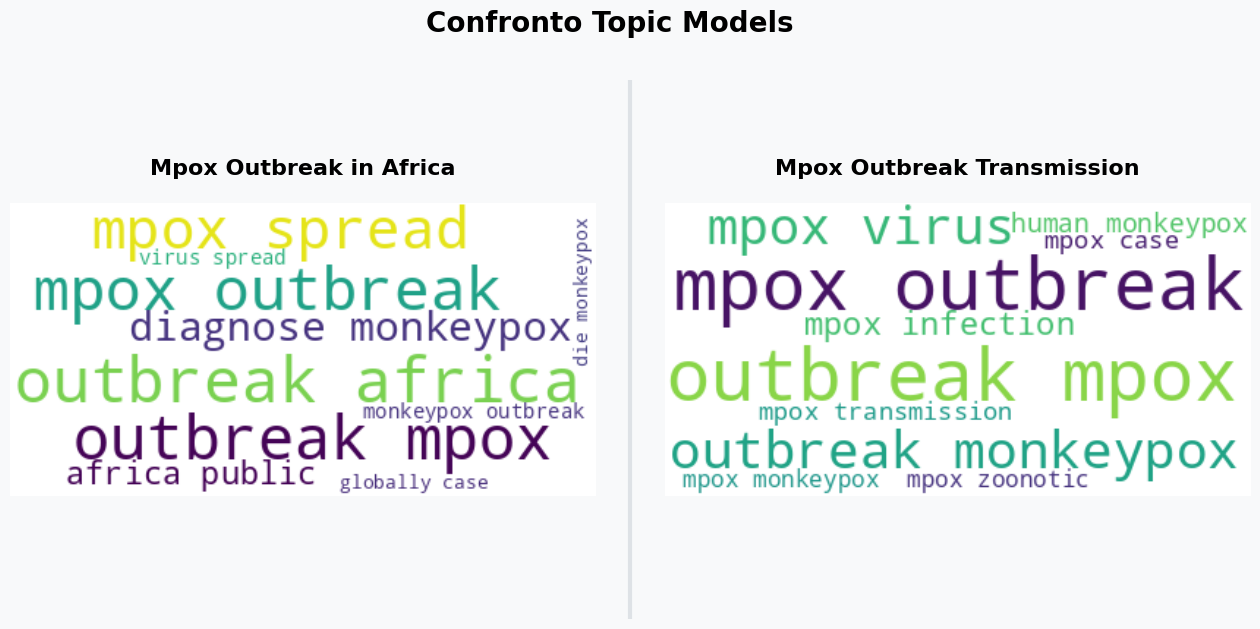

In [ ]:
models_metrics.compare_wordcloud_topics(105,14)

In [11]:
models_metrics.print_corpus_metrics()

Corpus Closeness: 0.4522773954859722
Corpus Uniqueness: 0.5477226045140279
Corpus Alignment: 0.2676525235567512


In [13]:
models_metrics.print_weighted_corpus_metrics()

Corpus Closeness: 0.33227433603656326
Corpus Uniqueness: 0.6677256639634367
Corpus Alignment: 0.20299306078087118


In [12]:
models_metrics.print_weighted_corpus_metrics()

Corpus Closeness: 0.43781177716467407
Corpus Uniqueness: 0.5621882228353259
Corpus Alignment: 0.24900370649053868


In [14]:
a = models_metrics.get_topic_closeness().sort_values(by='Closeness',ascending=False)

In [ ]:
topic_ids = [ key for key in model_1.topic_labels_.keys() ]

In [15]:
model_1_label = pd.DataFrame({'id': topic_ids,
                              'Topic_model_1_label': model_1.custom_labels_} )

In [16]:
topic_ids_2 = [ key for key in model_2.topic_labels_.keys() ]

In [17]:
model_2_label = pd.DataFrame({'id': topic_ids_2,
                              'Topic_model_2_label': model_2.custom_labels_} )

In [33]:
model_2.set_topic_labels({
23: "Antimicrobial Resistance in Acinetobacter baumannii",
28: "Campylobacter Infections and Prevalence",
29: "Tick-Borne Pathogens and Lyme-Related Diseases",
35: "Shiga Toxin–Producing E. coli O157 Infections",
39: "Zoonotic Toxoplasma gondii Infection and Prevalence",
44: "Carbapenem Resistance and Carbapenemase-Producing Bacteria",
46: "Antimicrobial Resistance in Neisseria gonorrhoeae",
52: "HIV-1 Drug Resistance and Antiretroviral Therapy",
54: "ESBL-Producing Enterobacteriaceae Infections",
57: "Coxiella burnetii Infection and Q Fever Epidemiology",
62: "HIV-1 and Primate Lentivirus Replication and Evolution",
65: "Swine Influenza Viruses and Transmission",
70: "Cryptosporidium Genotypes and Infection Epidemiology",
81: "Hantavirus Infections and Associated Diseases",
82: "Antiviral Resistance in Influenza Viruses",
109:	"Dengue, Chikungunya, and Zika Arbovirus Surveillance",
116:	"SARS-CoV-2 Seroprevalence and Population Exposure",
118:	"Ceftazidime–Avibactam and Resistance in Enterobacterales",
120:	"Zoonotic Echinococcosis and Cystic Hydatid Disease",
125:	"Antifungal Resistance in Aspergillus and Invasive Aspergillosis",
129:	"Recombinant Baculovirus Expression Systems",
134:	"Meningococcal Serogroups and Vaccine Coverage",
138:	"Nosocomial Bloodstream Infections and Bacteremia",
140:	"Culicoides Vectors and Bluetongue Transmission",
142:	"Bartonella Infections and Zoonotic Transmission",
146:	"Zoonotic Trichinellosis and Trichinella Prevalence",
150:	"Invasive Group A Streptococcal Infections (iGAS)",
153:	"Canine Dirofilariasis and Dirofilaria Infections",
158:	"COVID-19 Mortality and Severe Disease Outcomes",
160:	"COVID-19 Exposure and Infection in Healthcare Workers",
166:	"African Trypanosomiasis in Humans and Animals",
169:	"Rodent-Borne Pathogens and Zoonotic Helminths",
172:	"Anticoagulation Therapy and Thromboembolic Disorders",
175:	"Anaplasma Infections in Humans and Animals",
179:	"Avian Influenza H7N9 Human Infections",
194:	"Nontuberculous Mycobacterial Infections and Prevalence",
195:	"Human Toxocariasis as a Neglected Zoonotic Disease",
196:	"Post-Acute COVID-19 Syndrome and Long COVID",
197:	"Porcine Reproductive and Respiratory Syndrome Virus (PRRSV) Genetic Diversity",
199:	"Vancomycin-Resistant Enterococcus faecium Infections",
200:	"COVID-19 Medical Imaging and Diagnostic Classification",
203:	"Zoonotic Enterocytozoon bieneusi Genotypes and Infections",
207:	"Porcine Coronaviruses and Enteric Disease Outbreaks",
208:	"Zoonotic Cysticercosis and Taeniasis Epidemiology",
212:	"Human Psittacosis and Avian Transmission",
222:	"Avian Influenza H9N2 Genetic Evolution and Diversity",
225:	"Zoonotic Fascioliasis and Fasciola hepatica Prevalence",
230:	"Zoonotic Retroviruses and Simian Foamy Virus Transmission",
231:	"HIV-1 Genetic Diversity and Circulating Recombinant Forms",
243:	"Endemic Human Coronaviruses and Respiratory Infections",
244:	"Human and Animal Adenovirus Genotypes and Outbreaks",
246:	"Rare and Atypical Hydatid Disease Manifestations",
247:	"Genetic diversity and reservoir role of bat-associated alpha- and betacoronaviruses.",
248:	"Feline Viral Diseases and Co-Infections",
249:	"Public Attitudes and Preventive Behaviors During COVID-19",
250:	"Tigecycline Susceptibility and Antimicrobial Resistance",
251:	"Filarial Diseases Elimination and Onchocerciasis Control",
252:	"Cystic and Alveolar Echinococcosis Pathogenesis",
255:	"Human Cytomegalovirus Replication and Infection",
257:	"Ebolavirus and Filovirus Outbreaks and Infections",
267:	"Antimicrobial Resistance and Diversity in Vibrio cholerae",
268:	"Zoonotic Sporotrichosis and Feline Transmission",
269:	"NDM-Producing Carbapenem-Resistant Enterobacteriaceae",
280:	"MRSA and Resistant Staphylococci in Companion Animals",
281:	"Porcine Circovirus Genetic Diversity and Infection",
282:	"Yersinia enterocolitica Strains and Pathogenicity",
283:	"Dengue Diagnosis, Serotypes, and Surveillance",
284:	"COVID-19 Antiviral Treatment and Clinical Trials",
287:	"Schistosomiasis Transmission, Control, and Elimination",
295:	"Diarrhoeagenic Escherichia coli Pathotypes and Enteric Infections",
296:	"Schistosoma japonicum Surveillance and Zoonotic Transmission",
303:	"Bacterial Ocular Infections and Keratitis",
310:	"Zoonotic Typhus Incidence and Vector Transmission",
311:	"Tick-Borne Encephalitis Virus Epidemiology and Surveillance",
316:	"Blastocystis Subtypes, Diversity, and Transmission",
323:	"Porcine Xenotransplantation and Zoonotic Safety",
327:	"Hydroxychloroquine Use and Prophylaxis in COVID-19",
331:	"Zoonotic Feline Dermatophytosis and Dermatophyte Identification",
344:	"HIV-1 Genotyping and Molecular Subtyping",
350:	"Canine Influenza Virus (H3N2/H3N8) and Cross-Species Transmission",
357:	"Ruminant Herpesviruses and Associated Diseases",
358:	"Canine Vector-Borne Diseases and Ehrlichiosis",
359:	"Stenotrophomonas maltophilia Bacteremia and Nosocomial Infections",
364:	"Procalcitonin-Guided Antibiotic Therapy in Sepsis",
367:	"Infective Endocarditis Epidemiology and Clinical Outcomes",
368:	"Therapeutic Drug Monitoring of Antiretroviral Therapy",
375:	"Oncolytic Virus Therapy and Antitumor Efficacy",
376:	"Bacterial Coinfections and Superinfections in Hospitalized COVID-19 Patients",
377:	"Zoonotic Angiostrongylus Infections and Neuroangiostrongyliasis",
378:	"Plasmid-Mediated Tigecycline Resistance Mechanisms",
380:	"Corticosteroid and Immunomodulatory Treatment in Severe COVID-19",
382:	"Pasteurella and Mannheimia Infections in Bovine Respiratory Disease",
383:	"Infectious Disease Transmission during the Hajj Pilgrimage",
387:	"HIV Genotypic Resistance Testing and Subtyping",
391:	"Nosocomial Infections in ECMO-Supported Patients",
392:	"Streptococcus equi subsp. zooepidemicus in Equine Diseases",
395:	"COVID-19, Vaccination, and Immunotherapy in Multiple Sclerosis Patients",
399:	"Cronobacter Species Diversity and Neonatal Infections",
409:	"Coagulase-Negative Staphylococci and Methicillin Resistance",
411:	"Immune and Thrombotic Thrombocytopenia Syndromes",
412:	"Carbapenem and β-Lactam Antibiotic Susceptibility Trends",
424:	"Avian Influenza (H5N1/H5N8) Epidemiology in Egypt"
})

In [ ]:
a = a.merge(model_1_label,how='inner',left_on='Topic_model_1',right_on='id')

In [20]:
a = a.merge(model_2_label,how='inner',left_on='Topic_model_2',right_on='id')

In [21]:
a = a.drop(columns=['id_x','id_y'])

In [20]:
a[ a['Closeness'] >= 0.20]

,Topic_model_1,Topic_model_2,Topic_label_model_1,Topic_label_model_2,Couple_counts,Count,Closeness
95,105,14,Mpox Outbreak in Africa,Mpox Outbreak Transmission,99,104,0.951923
56,72,75,Zika Outbreak and Risk,Zika Virus Outbreaks,133,149,0.892617
142,138,115,Covid Contact Tracing App,Covid-19 Contact Tracing App,65,73,0.890411
152,149,105,Antibiotic Misuse in Farming,Animal Antimicrobial Use,61,70,0.871429
52,59,1,Tuberculosis Treatment Challenges,Tuberculosis Resistance and Control,150,175,0.857143
...,...,...,...,...,...,...,...
184,46,421,Haemophilia Blood Scandal,Transfusion Safety and Surveillance,47,221,0.212670
300,131,336,Vaccination Mandate Policy,Occupational Health and Safety in Workplaces,17,80,0.212500
128,25,123,Decriminalizing Drug Use Approach,Nonfatal Overdose Surveillance,73,347,0.210375
112,16,198,Vaccine Development and Supply,Childhood Vaccination Coverage,87,426,0.204225


In [14]:
a[ a['Closeness'] >= 0.5]

,Topic_model_1,Topic_model_2,Topic_label_model_1,Topic_label_model_2,Couple_counts,Count,Closeness
84,105,14,Mpox Outbreak in Africa,Mpox Outbreak Transmission,100,104,0.961538
51,72,75,Zika Outbreak and Risk,Zika Virus Outbreaks,136,149,0.912752
141,138,115,Covid Contact Tracing App,Covid-19 Contact Tracing App,65,73,0.890411
44,59,1,Tuberculosis Treatment Challenges,Tuberculosis Resistance and Control,155,175,0.885714
148,149,105,Antibiotic Misuse in Farming,Animal Antimicrobial Use,61,70,0.871429
24,38,198,Vaccine Equity and Access,Childhood Vaccination Coverage,221,256,0.863281
117,117,119,Pandemic Preparedness Failure,Healthcare System Preparedness for Pandemics,78,92,0.847826
38,49,155,Care Safety in England,Covid-19 Resident Care in Nursing Homes,172,207,0.830918
60,64,6,African Omicron Variant Spread,SARS-CoV-2 Genomic Evolution,127,161,0.788820
109,107,155,Aged Care Infection Outbreak,Covid-19 Resident Care in Nursing Homes,81,103,0.786408


In [22]:
a[ a['Topic_model_1'] == 18 ]

,Topic_model_1,Topic_model_2,Couple_counts,Count,Closeness,Topic_model_1_label,Topic_model_2_label
324,18,239,17,390,0.043590,LGBTQ Rights Struggle,HIV and COVID-19 Interaction
464,18,144,10,390,0.025641,LGBTQ Rights Struggle,HIV Risk and Transmission Status
1322,18,11,2,390,0.005128,LGBTQ Rights Struggle,Mental Health Impact of COVID-19
1598,18,34,1,390,0.002564,LGBTQ Rights Struggle,National Cancer Surveillance and Risk
1599,18,385,1,390,0.002564,LGBTQ Rights Struggle,HIV and Hypertension Prevalence in Adolescents
1600,18,258,1,390,0.002564,LGBTQ Rights Struggle,Adolescent Athlete Injury Surveillance
1601,18,294,1,390,0.002564,LGBTQ Rights Struggle,HIV Prevention and Prep Adherence


In [16]:
b = models_metrics.get_topic_uniqueness().sort_values(by='Closeness',ascending=False)

In [35]:
b = b.merge(model_1_label,how='inner',left_on='Topic_model_1',right_on='id')
b = b.merge(model_2_label,how='inner',left_on='Topic_model_2',right_on='id')
b = b.drop(columns=['id_x','id_y'])

In [17]:
b[ b['Closeness']>= 0.5].head(20)

,Topic_model_1,Topic_model_2,Topic_label_model_1,Topic_label_model_2,Couple_counts,Count,Closeness
54,84,-1,Cultural Heritage Attractions,-1_covid-19 pandemic_antimicrobial resistance_infectious disease_public health,130,130,1.000000
73,100,-1,Dedicated Teacher's Life Pursuit,-1_covid-19 pandemic_antimicrobial resistance_infectious disease_public health,112,112,1.000000
169,178,-1,Rwandan Genocide Impact,-1_covid-19 pandemic_antimicrobial resistance_infectious disease_public health,50,50,1.000000
94,113,-1,Housing Market Trends,-1_covid-19 pandemic_antimicrobial resistance_infectious disease_public health,93,94,0.989362
1,5,-1,Retail Sale Decline Trends,-1_covid-19 pandemic_antimicrobial resistance_infectious disease_public health,684,693,0.987013
57,83,-1,Guardian Report Highlights,-1_covid-19 pandemic_antimicrobial resistance_infectious disease_public health,128,130,0.984615
55,80,-1,Zuma Leadership in Africa,-1_covid-19 pandemic_antimicrobial resistance_infectious disease_public health,130,133,0.977444
58,81,-1,Diverse Cinema Success,-1_covid-19 pandemic_antimicrobial resistance_infectious disease_public health,128,132,0.969697
14,23,-1,Africa Poverty Reduction Pact,-1_covid-19 pandemic_antimicrobial resistance_infectious disease_public health,352,363,0.969697
67,94,-1,Passionate Culinary Experience,-1_covid-19 pandemic_antimicrobial resistance_infectious disease_public health,117,121,0.966942


In [18]:
alignment_totale = models_metrics.get_topic_alignment()['Alignment'].sum()

In [19]:
models_metrics.get_topic_closeness()['Topic_model_1'].sort_values().unique()

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 101, 102, 103, 104, 105,
       106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118,
       119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131,
       132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144,
       145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157,
       158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170,
       171, 172, 173, 174, 175, 176, 177])

### Cambiare metrica per alignment?

In [40]:
alignment_totale / models_metrics.n_topics_model_1

np.float64(0.2676525235567512)

In [41]:
alignment_totale / len(models_metrics.get_topic_alignment())

np.float64(0.27221478248101394)

### Model 2 -> Model 1

In [21]:
inverse_models_metrics = BTM(model_1=model_2,model_2=model_1,ids_1=ids_2,texts_1=texts_2,embeddings_1=embeddings_2,texts_2=texts,embeddings_2=embeddings)

2026-02-04 10:53:31,969 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
2026-02-04 10:53:32,266 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


Threshold:0.2878860831260681


In [22]:
inverse_models_metrics.evaluate_metrics()

In [46]:
inverse_models_metrics.print_corpus_metrics()

Corpus Closeness: 0.5680036790096502
Corpus Uniqueness: 0.4319963209903497
Corpus Alignment: 0.31133431629279557


In [47]:
inverse_models_metrics.print_weighted_corpus_metrics()

Corpus Closeness: 0.5772453029733501
Corpus Uniqueness: 0.4227546970266499
Corpus Alignment: 0.31535859226177204


In [26]:
x = inverse_models_metrics.get_topic_closeness().sort_values(by='Closeness',ascending=False)

In [27]:
x[ x['Closeness'] >= 0.5 ]

,Topic_model_1,Topic_model_2,Topic_label_model_1,Topic_label_model_2,Couple_counts,Count,Closeness
128,196,35,Post-Acute COVID-19 Syndrome and Long COVID,Long-term Covid Symptoms,227,227,1.000000
47,75,72,Zika Virus Outbreaks,Zika Outbreak and Risk,489,492,0.993902
311,360,147,Pregnancy and Influenza Vaccination,Maternal Vaccination Guidance,100,101,0.990099
73,105,149,Animal Antimicrobial Use,Antibiotic Misuse in Farming,376,383,0.981723
48,79,3,Ebola Outbreak Response in Africa,Ebola Outbreak Response,474,488,0.971311
...,...,...,...,...,...,...,...
4,3,21,Infection Control and Prevention,Hospital Infection Control Improvement,1683,3302,0.509691
247,168,99,HPV Prevalence and Infection Trends,HPV Vaccination Program for Girls,129,255,0.505882
243,162,177,HIV Surveillance and Care,HIV Testing and Diagnosis,131,260,0.503846
325,227,63,Falciparum Genetic Diversity in Malaria Transmission,Malaria Vaccine Initiative,96,191,0.502618


In [28]:
y = inverse_models_metrics.get_topic_uniqueness().sort_values(by='Closeness',ascending=False)

In [29]:
y[ y['Closeness'] >= 0.5 ]

,Topic_model_1,Topic_model_2,Topic_label_model_1,Topic_label_model_2,Couple_counts,Count,Closeness
90,129,-1,Recombinant Baculovirus Expression Systems,-1_public health_emphasize importance_pandemic_importance,315,315,1.000000
184,260,-1,Endotoxin-Induced Inflammatory Response,-1_public health_emphasize importance_pandemic_importance,166,166,1.000000
181,255,-1,Human Cytomegalovirus Replication and Infection,-1_public health_emphasize importance_pandemic_importance,169,170,0.994118
340,381,-1,DNA Repair and Genome Stability,-1_public health_emphasize importance_pandemic_importance,92,93,0.989247
339,375,-1,Oncolytic Virus Therapy and Antitumor Efficacy,-1_public health_emphasize importance_pandemic_importance,93,95,0.978947
...,...,...,...,...,...,...,...
492,324,-1,Respiratory Support Methods,-1_public health_emphasize importance_pandemic_importance,62,122,0.508197
392,262,-1,BVDV Seroprevalence in Dairy Herds,-1_public health_emphasize importance_pandemic_importance,83,164,0.506098
636,401,-1,Gastrointestinal Parasites in Baboons,-1_public health_emphasize importance_pandemic_importance,43,85,0.505882
51,34,-1,National Cancer Surveillance and Risk,-1_public health_emphasize importance_pandemic_importance,468,928,0.504310


In [30]:
inverse_models_metrics.topic_alignment.sort_values(by='Alignment',ascending=False)

,Topic_model_1,Topic_label_model_1,Count,Alignment,Weigth
195,196,Post-Acute COVID-19 Syndrome and Long COVID,227,1.000000,227.0
75,75,Zika Virus Outbreaks,492,0.993902,489.0
358,360,Pregnancy and Influenza Vaccination,101,0.990099,100.0
105,105,Animal Antimicrobial Use,383,0.981723,376.0
79,79,Ebola Outbreak Response in Africa,488,0.971311,474.0
...,...,...,...,...,...
48,48,Potato Mosaic Virus Infection,714,0.014006,10.0
59,59,Pfas in Municipal Biosolids and Sludge Treatment,632,0.011076,7.0
379,381,DNA Repair and Genome Stability,93,0.010753,1.0
346,348,Fully Polarimetric Wastewater Monitoring System,108,0.009259,1.0


### New proposed topic alignment

In [31]:
inverse_alignment_totale = inverse_models_metrics.get_topic_alignment()['Alignment'].sum()

In [32]:
inverse_alignment_totale / inverse_models_metrics.n_topics_model_1

np.float64(0.31133431629279557)

In [33]:
inverse_alignment_totale / len(inverse_models_metrics.get_topic_alignment())

np.float64(0.3128063461570641)